In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
file_name = "forex_trading_data.xlsx"
df = pd.read_excel(file_name)

In [14]:
print("--- INFO ---")
df.info()

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Open Time   1081 non-null   object 
 1   Type        1081 non-null   object 
 2   Volume      1071 non-null   float64
 3   Symbol      1071 non-null   object 
 4   Price       1071 non-null   object 
 5   Close Time  1081 non-null   object 
 6   Price.1     1071 non-null   object 
 7   Commission  516 non-null    float64
 8   Swap        169 non-null    float64
 9   Profit      1081 non-null   object 
dtypes: float64(3), object(7)
memory usage: 84.6+ KB


In [15]:
print("\n--- HEAD ---")
print(df.head())


--- HEAD ---
          Open Time  Type  Volume  Symbol     Price        Close Time  \
0  2026.06.18 19:36  Sell    0.01  XAUUSD  4 218.88  2026.06.18 22:11   
1  2026.06.17 20:33   Buy    0.02  XAUUSD  4 368.67  2026.06.17 21:00   
2  2026.06.17 20:33   Buy    0.02  XAUUSD  4 369.57  2026.06.17 21:00   
3  2026.06.17 20:33   Buy    0.01  XAUUSD  4 367.76  2026.06.17 20:35   
4  2026.06.17 20:33   Buy    0.01  XAUUSD  4 368.26  2026.06.17 20:33   

    Price.1  Commission  Swap Profit  
0  4 205.57       -0.08   NaN  13.31  
1  4 345.88       -0.14   NaN -45.58  
2  4 368.66       -0.14   NaN  -1.82  
3  4 373.61       -0.08   NaN   5.85  
4  4 381.99       -0.08   NaN  13.73  


In [16]:
# data cleaning
for col in ['Price', 'Price.1', 'Profit']:
    df[col] = df[col].astype(str).str.replace(r'\s+', '', regex=True).replace('nan', np.nan).astype(float)

In [17]:
# time conversion
df['Open Time'] = pd.to_datetime(df['Open Time'], format='%Y.%m.%d %H:%M', errors='coerce')
df['Close Time'] = pd.to_datetime(df['Close Time'], format='%Y.%m.%d %H:%M', errors='coerce')

In [20]:
# filling null values for finanicial adjustments
df['Commission'] = df['Commission'].fillna(0)
df['Swap'] = df['Swap'].fillna(0)
df = df.dropna(subset=['Symbol'])

In [21]:
df['Net Profit'] = df['Profit'] + df['Commission'] + df['Swap']

In [22]:
df = df.sort_values(by='Close Time').reset_index(drop=True)

In [23]:
df.info()
print(df['Profit'].sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Open Time   1071 non-null   datetime64[ns]
 1   Type        1071 non-null   object        
 2   Volume      1071 non-null   float64       
 3   Symbol      1071 non-null   object        
 4   Price       1071 non-null   float64       
 5   Close Time  1071 non-null   datetime64[ns]
 6   Price.1     1071 non-null   float64       
 7   Commission  1071 non-null   float64       
 8   Swap        1071 non-null   float64       
 9   Profit      1071 non-null   float64       
 10  Net Profit  1071 non-null   float64       
dtypes: datetime64[ns](2), float64(7), object(2)
memory usage: 92.2+ KB
305403.68


In [24]:
print("--- TRADING SUMMARY ---")
print(f"Total Trades Taken: {len(df)}")
print(f"Total Gross Profit: ${df['Profit'].sum():.2f}")
print(f"Total Net Profit (after fees): ${df['Net Profit'].sum():.2f}")

# Calculate Win Rate
df['Outcome'] = np.where(df['Net Profit'] > 0, 'Win', 'Loss')
win_rate = df['Outcome'].value_counts(normalize=True) * 100
print(f"\nWin Rate:\n{win_rate}")

--- TRADING SUMMARY ---
Total Trades Taken: 1071
Total Gross Profit: $305403.68
Total Net Profit (after fees): $304520.85

Win Rate:
Outcome
Win     77.310924
Loss    22.689076
Name: proportion, dtype: float64


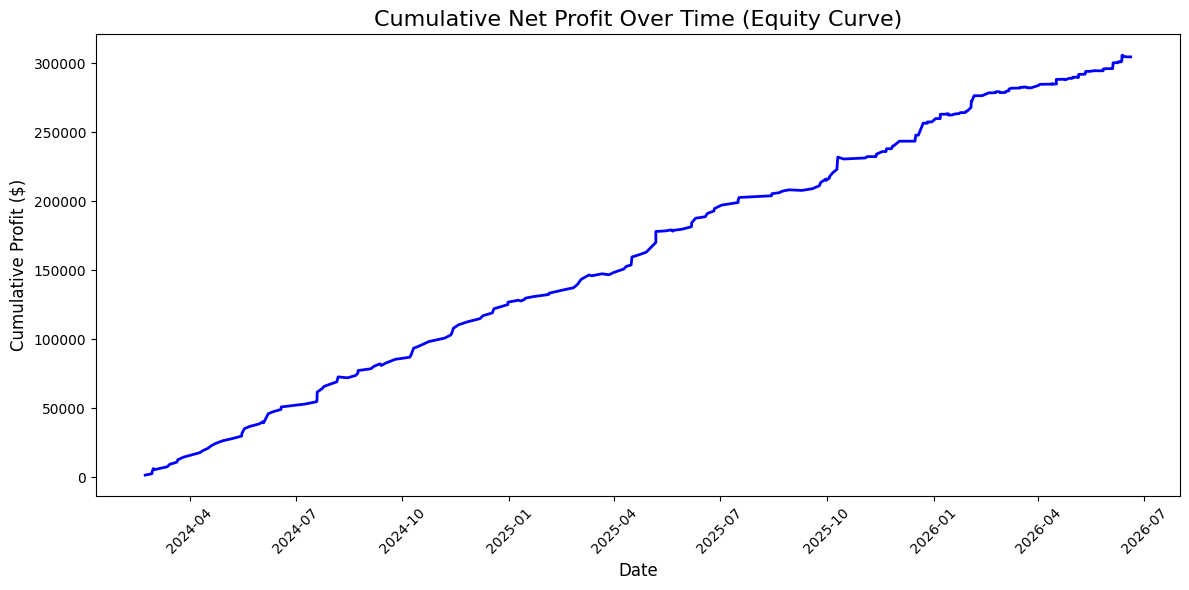

In [27]:
import matplotlib.pyplot as plt

#This creates a timeline chart to visualize how your account balance grew or shrank over time
df['Cumulative Profit'] = df['Net Profit'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(df['Close Time'], df['Cumulative Profit'], color='blue', linewidth=2)
plt.title('Cumulative Net Profit Over Time (Equity Curve)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Profit ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

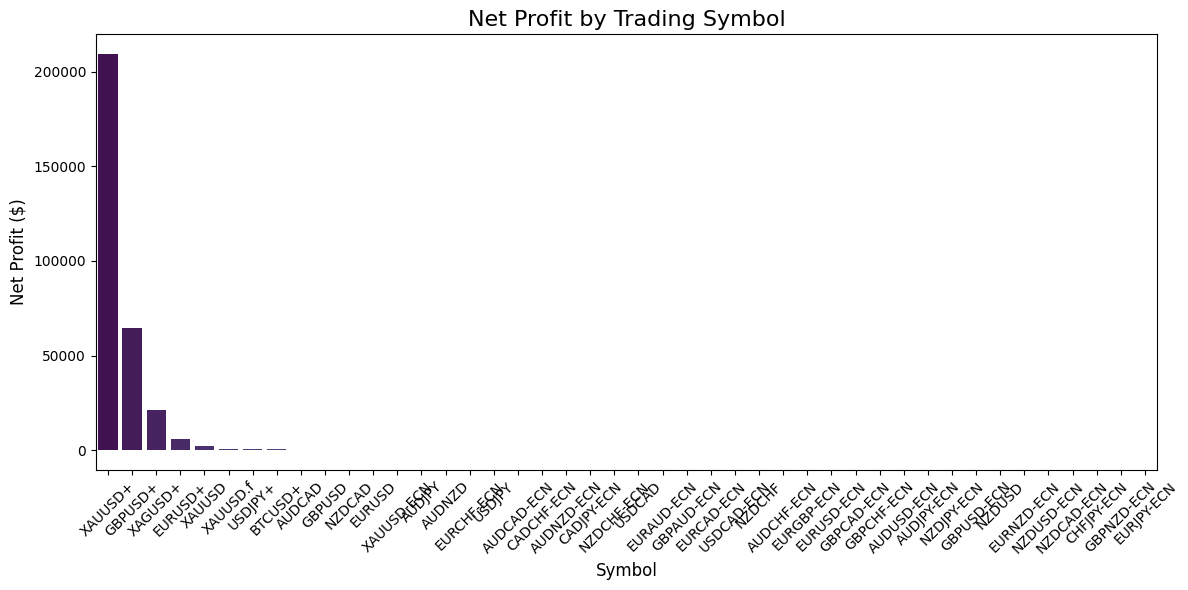

In [30]:
import seaborn as sns

#This creates a bar chart showing which currency pairs or commodities (like XAUUSD) made you the most money.
profit_by_symbol = df.groupby('Symbol')['Net Profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=profit_by_symbol, x='Symbol', y='Net Profit', hue='Symbol', palette='viridis', legend=False)
plt.title('Net Profit by Trading Symbol', fontsize=16)
plt.xlabel('Symbol', fontsize=12)
plt.ylabel('Net Profit ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

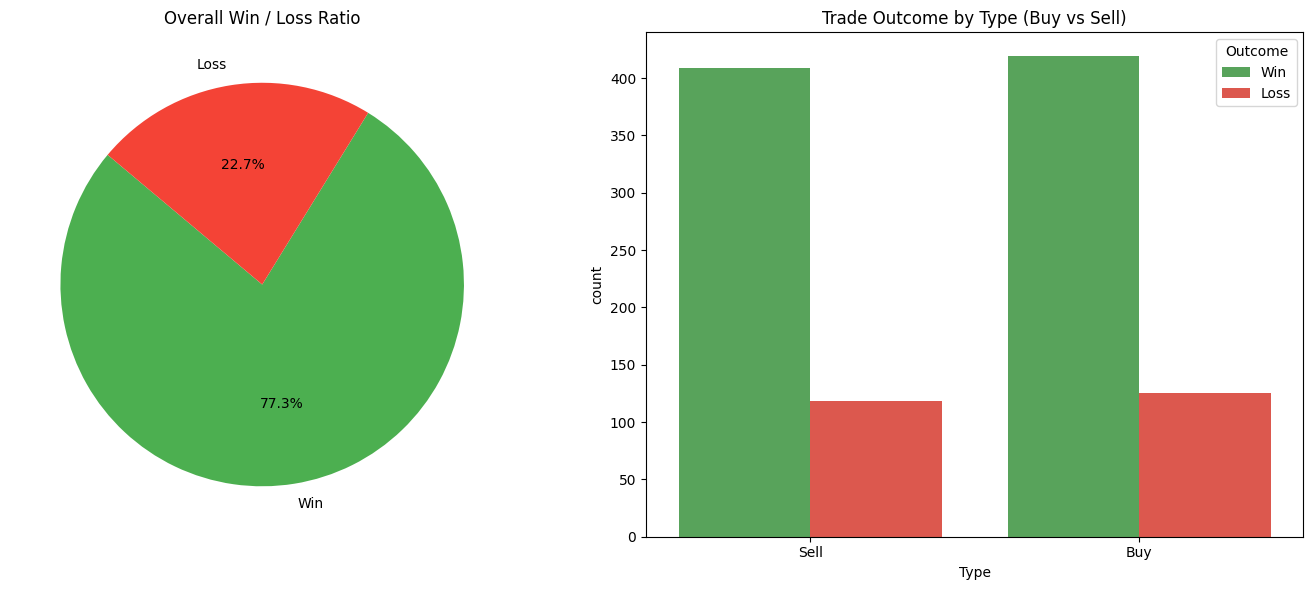

In [32]:
#This creates two visual panels: A pie chart of your wins vs. losses, and a bar chart comparing how
# well your "Buy" (Long) trades did vs. your "Sell" (Short) trades.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie Chart for Win/Loss
outcome_counts = df['Outcome'].value_counts()
axes[0].pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=140)
axes[0].set_title('Overall Win / Loss Ratio')

# Bar Chart for Buy vs Sell outcomes
sns.countplot(data=df, x='Type', hue='Outcome', ax=axes[1], palette={'Win': '#4CAF50', 'Loss': '#F44336'})
axes[1].set_title('Trade Outcome by Type (Buy vs Sell)')

plt.tight_layout()
plt.show()